# 3 · Algebraic filters for tensor tomography
Companion notebook to *Fast reconstruction of tensor tomographic X-ray scattering data for real-time applications*
(Mesquita Antunes, Pelt & Batenburg, Optics Express, [doi:10.1364/OE.597352](https://doi.org/10.1364/OE.597352)).

We reconstruct the simulated projections with $k$ Landweber iterations, compute one algebraic filter per tensor
component (Algorithm 1), and reconstruct again with a single filtering + back-projection step (Algorithm 2),
as in Section 4.1 / Fig. 4. Run notebooks 01 and 02 first.

In [1]:
# Colab only: fetch the repository and install mumott (skipped everywhere else)
import os, sys
if 'google.colab' in sys.modules and not os.getcwd().endswith('notebooks'):
    !git clone -q https://github.com/mesqant/algebraic-filters-tt
    %pip install -q mumott==2.1 "scipy<1.17" colorcet
    %cd algebraic-filters-tt/notebooks

In [2]:
# Imports (mumott's INFO logging is silenced; its DeprecationWarnings about entry names in the phantom file are harmless)
import logging
from functools import partial
from pathlib import Path
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import colorcet  # registers the 'cet_*' colormaps
from tqdm.auto import tqdm
logging.getLogger('mumott').setLevel(logging.WARNING)
from mumott.data_handling import DataContainer
from mumott.methods.projectors import SAXSProjector, SAXSProjectorCUDA

In [3]:
# Compute backend: GPU (cupy + mumott's CUDA projector) if available, else CPU (numpy + mumott's numba projector)
try:
    import cupy as cp
    gpu_available = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    gpu_available = False
xp = cp if gpu_available else np
to_numpy = cp.asnumpy if gpu_available else np.asarray  # device → host copy (no-op on CPU)
f'GPU: {gpu_available}'

'GPU: True'

In [4]:
# Build the previous notebooks' outputs if they are missing (e.g. on a fresh Colab runtime)
data_dir = Path('../data')
for notebook, output in [('01_representations', 'phantom_representations.npz'), ('02_forward_models', 'mixing_operators.npz')]:
    if not (data_dir / output).exists():
        !jupyter nbconvert --to notebook --execute {notebook}.ipynb --output-dir /tmp

In [5]:
# Load the phantom representations (notebook 01) and mixing operators (notebook 02)
phantom = np.load(data_dir / 'phantom_representations.npz')
mixing = np.load(data_dir / 'mixing_operators.npz')
volume_shape = phantom['tensor'].shape[:3]
view_step = int(mixing['view_step'])  # views used in notebook 02: every view_step-th of the 417
{name: mixing[name].shape for name in ['spherical', 'directional', 'tensor']}

{'spherical': (417, 8, 28), 'directional': (417, 8, 7), 'tensor': (417, 3, 6)}

## Forward model (as in notebook 02)

In [6]:
# Acquisition geometry, resized to the padded volume and subsampled like in notebook 02
geometry = DataContainer(str(data_dir / 'M_sim_1.0e+01.h5')).geometry
geometry.volume_shape = volume_shape
geometry.projection_shape = volume_shape[:2]
for view in reversed(range(len(geometry))):
    if view % view_step:
        del geometry[view]
len(geometry)

/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/mumott/data_handling/data_container.py:227: DeprecationWarning: Entry name rotations is deprecated. Use inner_angle instead.
  _deprecated_key_warning('rotations')
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/mumott/data_handling/data_container.py:236: DeprecationWarning: Entry name tilts is deprecated. Use outer_angle instead.
  _deprecated_key_warning('tilts')
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/mumott/data_handling/data_container.py:268: DeprecationWarning: Entry name offset_j is deprecated. Use j_offset instead.
  _deprecated_key_warning('offset_j')
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/mumott/data_handling/data_container.py:278: DeprecationWarning: Entry name offset_k is deprecated. Use k_offset instead.
  _deprecated_key_warning('offset_k')


417

In [7]:
# Tomographic projector W̄, forward model A = W̄Y and adjoint Aᵀ = YᵀW̄ᵀ
projector = SAXSProjectorCUDA(geometry) if gpu_available else SAXSProjector(geometry)

def to_projector(array):  # mumott projectors take host arrays (float32 for CUDA, float64 for CPU)
    return np.asarray(to_numpy(array), dtype=projector.dtype)

def forward(volume, mixing):
    projections = xp.asarray(projector.forward(to_projector(volume)), dtype=xp.float32)
    return xp.einsum('vijc,vsc->vijs', projections, mixing)

def backward(projections, mixing):
    unmixed = xp.einsum('vijs,vsc->vijc', projections, mixing)
    return xp.asarray(projector.adjoint(to_projector(unmixed)), dtype=xp.float32)

In [8]:
# Choose the representation: 'tensor' (C = 6), 'directional' (C = 7) or 'spherical' (C = 28, GPU recommended)
representation = 'tensor'
x_true = xp.asarray(phantom[representation])
Y = xp.asarray(mixing[representation])
A = partial(forward, mixing=Y)
At = partial(backward, mixing=Y)
n_components = x_true.shape[-1]
x_true.shape, Y.shape

((57, 57, 57, 6), (417, 3, 6))

In [9]:
# Simulated projections b = A x_true
b = A(x_true)
b.shape

(417, 57, 57, 3)

## Landweber step size α (power method, Algorithm 1 lines 2–8)

In [10]:
# Estimate λ_max(AᵀA) with 8 power iterations started from the back-projected data
v = At(b)
v /= xp.linalg.norm(v)
lambda_estimates = []
for _ in range(8):
    w = At(A(v))
    lambda_estimates.append(float(xp.vdot(v, w)))  # Rayleigh quotient vᵀAᵀAv
    v = w / xp.linalg.norm(w)
lambda_estimates

[14129.8388671875,
 16529.5390625,
 17028.01171875,
 17201.64453125,
 17279.58203125,
 17316.958984375,
 17335.2109375,
 17344.201171875]

/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


'α = 1.095e-04'

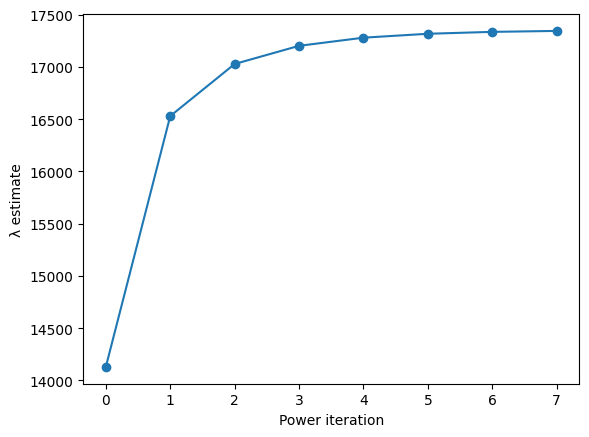

In [11]:
# Show the convergence of the power method and set α close to (but under) the upper bound 2/λ_max
plt.plot(lambda_estimates, 'o-')
plt.xlabel('Power iteration')
plt.ylabel('λ estimate')
alpha = 1.9 / lambda_estimates[-1]
f'α = {alpha:.3e}'

## Landweber reconstruction (Eq. 8)

In [12]:
# Landweber reconstruction Qb = α Σ_i (I − αAᵀA)^i Aᵀb, tracking the data residual
# Note: starting from the i = 0 term αAᵀb, k iterations add k more terms (k+1 in total, vs. i = 0..k−1 in Eq. 10).
#       The filters below use the same convention, so both reconstructions correspond to the same Landweber iterate.
def landweber(b, k):
    term = At(b)
    total = term.copy()
    residual = b.copy()
    residual_norms = []
    for _ in tqdm(range(k), desc='Landweber'):
        forward_term = A(term)
        term -= alpha * At(forward_term)
        total += term
        residual -= alpha * forward_term
        residual_norms.append(float(xp.linalg.norm(residual)))
    return alpha * total, residual_norms

In [13]:
# Reconstruct with k = 50 iterations, as in the paper
k = 50
x_landweber, residual_norms = landweber(b, k)
x_landweber.shape

Landweber:   0%|          | 0/50 [00:00<?, ?it/s]

(57, 57, 57, 6)

/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/home/andre/miniconda3/envs/filters2/lib/python3.11/site-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )

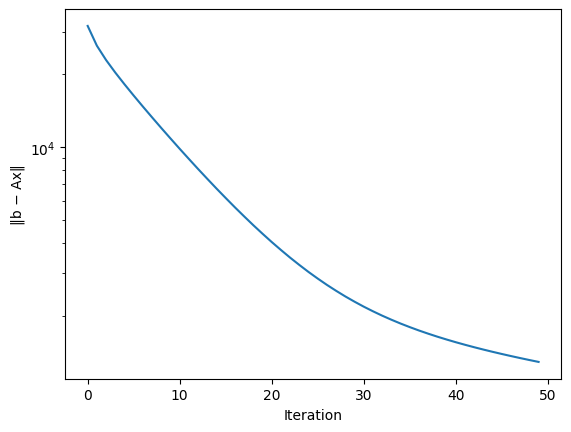

In [14]:
# Show the data residual per iteration
plt.semilogy(residual_norms)
plt.xlabel('Iteration')
plt.ylabel('‖b − Ax‖');

## Algebraic filters (Algorithm 1, lines 9–13)

In [15]:
# Adjoint reconstruction operator Qᵀ = α A Σ_i (I − αAᵀA)^i, applied to a tensor volume (same k+1 term convention)
def landweber_adjoint(volume, k):
    term = volume.copy()
    total = term.copy()
    for _ in tqdm(range(k), desc='Landweber (adjoint)', leave=False):
        term -= alpha * At(A(term))
        total += term
    return alpha * A(total)

In [16]:
# Unit impulse at the central voxel of component c
def central_impulse(c):
    delta = xp.zeros_like(x_true)
    delta[volume_shape[0] // 2, volume_shape[1] // 2, volume_shape[2] // 2, c] = 1
    return delta

In [17]:
# Compute the filter q_c = Qᵀδ_c for every component; filters are written to disk one at a time (low memory),
# and can be reused for any sample measured with this geometry
filters_path = data_dir / f'algebraic_filters_{representation}_{k}iter_{len(geometry)}views.npy'
filters = np.lib.format.open_memmap(filters_path, mode='w+', dtype=np.float32, shape=(n_components,) + b.shape)
for c in tqdm(range(n_components), desc='Filters'):
    filters[c] = to_numpy(landweber_adjoint(central_impulse(c), k))
filters.flush()
filters.shape, f'{filters.nbytes / 1e6:.0f} MB'

Filters:   0%|          | 0/6 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

((6, 417, 57, 57, 3), '98 MB')

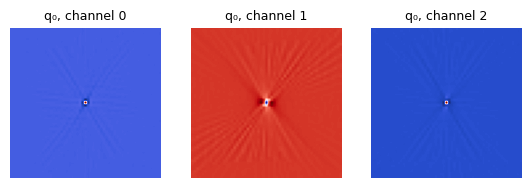

In [18]:
# Show the filter of component 0 for one view, per detector channel
view = len(geometry) // 3
fig, axes = plt.subplots(1, b.shape[-1], figsize=(2.2 * b.shape[-1], 2.4))
for s, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(filters[0, view, :, :, s].T, cmap='cet_CET_D1A', origin='lower')
    ax.set_title(f'q₀, channel {s}', fontsize=9)
    ax.axis('off')

In [19]:
# The filters come from the adjoint (a correlation kernel) but are applied as a convolution below, as in the paper.
# The two agree for point-symmetric filters; the residual asymmetry ‖q − q[::-1, ::-1]‖ / ‖q‖ is a few percent, which
# changes the AF–Landweber MSE by < 0.1% (tensor representation)
asymmetry = np.sqrt(sum(np.sum((q - q[:, ::-1, ::-1]) ** 2) for q in filters)  # one component at a time (low memory)
                    / sum(np.sum(q ** 2) for q in filters))
f'relative asymmetry of the filters: {asymmetry:.1e}'

'relative asymmetry of the filters: 2.4e-02'

## Algebraic filter reconstruction (Algorithm 2)

In [20]:
# Filter the projections: for each component c and view, convolve every channel with q_c and sum over channels
b_host = to_numpy(b)
filtered = np.empty(b.shape[:3] + (n_components,), dtype=np.float32)
for c in tqdm(range(n_components), desc='Filtering'):
    for v in range(b.shape[0]):
        filtered[v, :, :, c] = scipy.signal.fftconvolve(b_host[v], filters[c, v], mode='same', axes=(0, 1)).sum(axis=-1)
filtered.shape

Filtering:   0%|          | 0/6 [00:00<?, ?it/s]

(417, 57, 57, 6)

In [21]:
# Back-project all components at once with the plain tomographic back-projector W̄ᵀ
x_af = projector.adjoint(to_projector(filtered)).astype(np.float32)
x_af.shape

(57, 57, 57, 6)

## Comparison with the ground truth and the Landweber reconstruction

In [22]:
# Restrict all volumes to the 'M' mask, on the host
mask = phantom['mask']
volumes = {'Ground truth': to_numpy(x_true), 'Landweber': to_numpy(x_landweber), 'Algebraic filters': x_af}
volumes = {name: np.where(mask[..., None], volume, 0) for name, volume in volumes.items()}

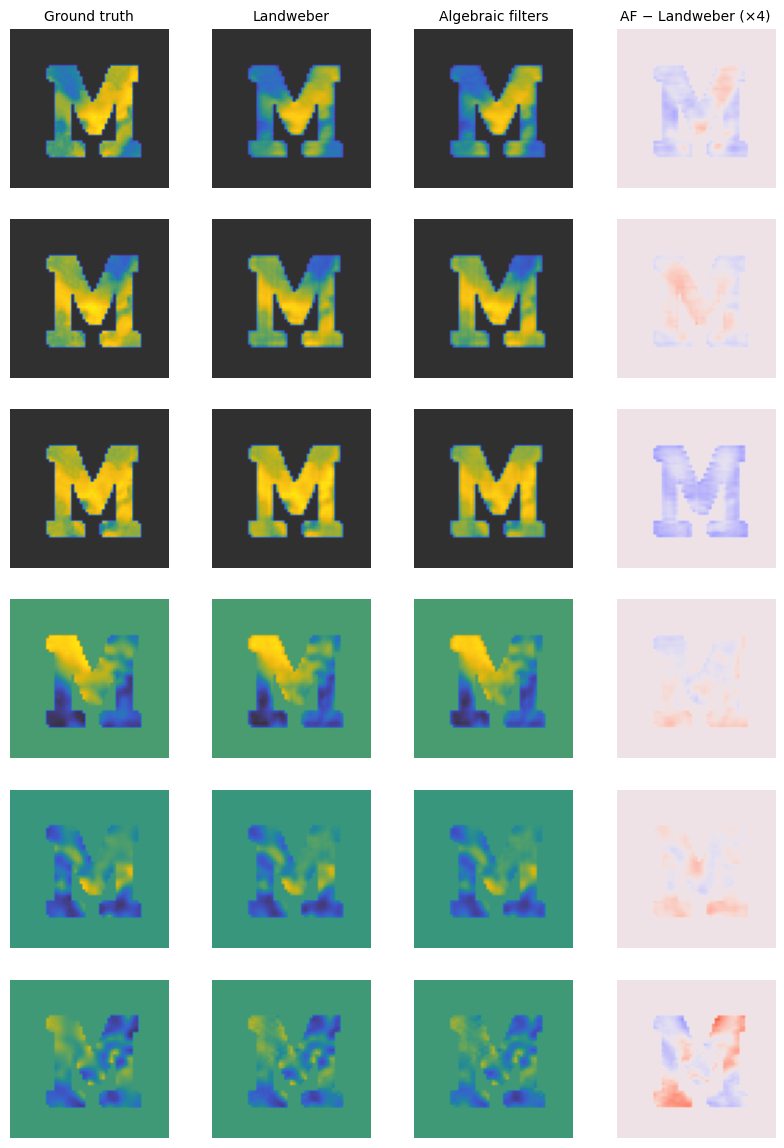

In [23]:
# Show the central slice of up to 6 components (cf. Fig. 4), with the AF − Landweber difference in the last column
slice_idx = volume_shape[1] // 2
n_shown = min(n_components, 6)
difference = volumes['Algebraic filters'] - volumes['Landweber']
fig, axes = plt.subplots(n_shown, 4, figsize=(10, 2.4 * n_shown), squeeze=False)
for c in range(n_shown):
    vmin, vmax = volumes['Ground truth'][..., c].min(), volumes['Ground truth'][..., c].max()
    for ax, (name, volume) in zip(axes[c], volumes.items()):
        ax.imshow(volume[:, slice_idx, :, c].T, cmap='cet_gouldian', origin='lower', vmin=vmin, vmax=vmax)
    axes[c, 3].imshow(difference[:, slice_idx, :, c].T, cmap='cet_CET_D1A', origin='lower', vmin=-(vmax - vmin) / 4, vmax=(vmax - vmin) / 4)
for ax, title in zip(axes[0], list(volumes) + ['AF − Landweber (×4)']):
    ax.set_title(title, fontsize=10)
for ax in axes.flat:
    ax.axis('off')

In [24]:
# Mean squared errors inside the mask (cf. Fig. 5 at k = 50)
def masked_mse(x, y):
    return float(np.mean((x[mask] - y[mask]) ** 2))

mse = {'Landweber vs GT': masked_mse(volumes['Landweber'], volumes['Ground truth']),
       'AF vs Landweber': masked_mse(volumes['Algebraic filters'], volumes['Landweber']),
       'AF vs GT': masked_mse(volumes['Algebraic filters'], volumes['Ground truth'])}
{name: f'{value:.3e}' for name, value in mse.items()}

{'Landweber vs GT': '1.678e-01',
 'AF vs Landweber': '1.990e-02',
 'AF vs GT': '2.161e-01'}